In [1]:
# Standard library
import sys
from pathlib import Path

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Clustering and dimensionality reduction
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Hierarchical clustering and statistical tests
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency

# Project-local setup
sys.path.append("../src")
from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG

set_project_style()
data_dir = Path("../data/processed")

In [2]:
# [Step 1]: Load data, define X and y

# Load the clustered patient-level table (output of Phase 3, notebook 02)
df = pd.read_parquet("../data/processed/patient_features_clustered.parquet")

# Predictor set: 9 baseline, treatment-naive features (see protocol.md, Phase 4 scope).
# Excluded by design:
#   - CCI, encounters_per_year      -> accumulate over years of follow-up, not available
#                                       at a single baseline visit
#   - on_metformin/insulin/other    -> near-deterministically leak the cluster label
#   - RACE, ETHNICITY (GENDER)      -> consistent with the equity-driven exclusion
#                                       already applied in Phase 3 clustering
baseline_features = [
    "AGE", "HbA1c", "Glucose", "BMI", "LDL", "HDL",
    "Triglycerides", "Creatinine", "creatinine_measured"
]

X = df[baseline_features]
y = df["cluster_label"]

# Sanity checks: shapes and class balance should match Phase 3 (73.9% / 5.3% / 20.8%)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts(normalize=True).round(3))

X.head()

X shape: (1763, 9)
y shape: (1763,)

Class distribution:
cluster_label
Mild, lower treatment intensity      0.739
Multimorbid, high care complexity    0.208
Dyslipidemic / metabolic             0.053
Name: proportion, dtype: float64


,AGE,HbA1c,Glucose,BMI,LDL,HDL,Triglycerides,Creatinine,creatinine_measured
PATIENT,,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,74,3.9,110.2,27.6,124.3,48.8,162.7,2.0,1
0005fc0b-a254-8215-d848-1a20685b750f,80,5.5,97.1,27.9,104.8,60.7,111.8,2.0,1
0012304f-0715-b5e9-efa2-ee32e57cfb57,50,6.2,99.6,30.7,125.5,53.2,108.1,0.9,0
00681a7d-5dad-ecfe-af77-b65f8da3fa15,77,5.6,70.0,28.3,112.8,52.0,181.2,0.9,0
007603dc-125f-14a7-4318-81aa596339c8,46,7.3,77.5,29.4,78.7,59.3,138.1,0.9,0


In [3]:
# [Step 2]: Outer holdout split + Stratified K-Fold setup

from sklearn.model_selection import train_test_split, StratifiedKFold

# Outer split: 80% train, 20% holdout test.
# stratify=y ensures both pieces keep the same ~74/21/5% class mix as the full dataset.
# random_state fixes the random seed, so the split is reproducible if you re-run the cell.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

# Stratified K-Fold object: this defines *how* the 5 folds will be built later,
# but doesn't do anything yet — we'll hand it to the model-selection step (Step 4).
# shuffle=True randomizes patient order before splitting into folds (important: if the
# parquet rows happen to be sorted by patient ID or by anything else, an unshuffled split
# could accidentally cluster similar patients into the same fold).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train shape: (1410, 9)
Test shape: (353, 9)

Train class distribution:
cluster_label
Mild, lower treatment intensity      0.739
Multimorbid, high care complexity    0.208
Dyslipidemic / metabolic             0.053
Name: proportion, dtype: float64

Test class distribution:
cluster_label
Mild, lower treatment intensity      0.739
Multimorbid, high care complexity    0.207
Dyslipidemic / metabolic             0.054
Name: proportion, dtype: float64


In [4]:
# [Step 3]: Scaling (fit on train only)

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform only, using train's statistics

# Sanity check: scaled train median should be ~0 for each feature (RobustScaler centers on median)
import pandas as pd
pd.DataFrame(X_train_scaled, columns=X_train.columns).median().round(2)

AGE                    0.0
HbA1c                  0.0
Glucose                0.0
BMI                    0.0
LDL                    0.0
HDL                    0.0
Triglycerides          0.0
Creatinine             0.0
creatinine_measured    0.0
dtype: float64

In [5]:
# [Step 4]: Baseline model (logistic regression) via Stratified K-Fold CV

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# class_weight="balanced" -> see explanation above: rare-class errors count more during training
# max_iter=1000 -> logistic regression is fit by iterative optimization; the default (100) can stop
#                  before converging with this many features/classes, so we give it more room
# random_state=42 -> reproducibility (some solvers have a stochastic component)
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

# cross_validate runs the model through all 5 folds of the `cv` object we built in Step 2,
# computing both metrics on each held-out fold and returning all 5 results per metric
cv_results = cross_validate(
    logreg, X_train_scaled, y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=False
)

print("Macro-F1 per fold: ", cv_results["test_f1_macro"].round(3))
print("Macro-F1 mean ± std:", cv_results["test_f1_macro"].mean().round(3), "±", cv_results["test_f1_macro"].std().round(3))

print("\nAccuracy per fold: ", cv_results["test_accuracy"].round(3))
print("Accuracy mean ± std:", cv_results["test_accuracy"].mean().round(3), "±", cv_results["test_accuracy"].std().round(3))

Macro-F1 per fold:  [0.835 0.876 0.879 0.899 0.897]
Macro-F1 mean ± std: 0.877 ± 0.023

Accuracy per fold:  [0.84  0.858 0.89  0.89  0.887]
Accuracy mean ± std: 0.873 ± 0.02


In [6]:
# [Step 4]: Baseline model (logistic regression) via Stratified K-Fold CV
# Note: Use pipeline to avoid scaling leakage across CV folds

from sklearn.pipeline import Pipeline

# Bundle scaler + model together. Inside cross_validate, this whole pipeline gets
# refit from scratch on each fold's training portion -- the scaler included.
pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

cv_results_pipe = cross_validate(
    pipe, X_train, y_train,   # note: raw, UNscaled X_train -- scaling now happens inside each fold
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=False
)

print("Macro-F1 per fold (pipeline):  ", cv_results_pipe["test_f1_macro"].round(3))
print("Macro-F1 mean ± std (pipeline):", cv_results_pipe["test_f1_macro"].mean().round(3), "±", cv_results_pipe["test_f1_macro"].std().round(3))

print("\nAccuracy per fold (pipeline):  ", cv_results_pipe["test_accuracy"].round(3))
print("Accuracy mean ± std (pipeline):", cv_results_pipe["test_accuracy"].mean().round(3), "±", cv_results_pipe["test_accuracy"].std().round(3))

Macro-F1 per fold (pipeline):   [0.835 0.876 0.879 0.899 0.897]
Macro-F1 mean ± std (pipeline): 0.877 ± 0.023

Accuracy per fold (pipeline):   [0.84  0.858 0.89  0.89  0.887]
Accuracy mean ± std (pipeline): 0.873 ± 0.02


**Step 4 — Baseline model: logistic regression (Stratified 5-Fold CV)**

**Setup**: `LogisticRegression(class_weight="balanced", max_iter=1000)`, wrapped in a
`Pipeline` with `RobustScaler` to avoid scaling leakage across CV folds. Evaluated via
`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` on the 1410-patient training
set (test holdout, n=353, untouched).

**Results**:
- Macro-F1: 0.877 ± 0.023 (range 0.835–0.899 across folds)
- Accuracy: 0.873 ± 0.020 (range 0.840–0.890 across folds)

**Interpretation**: macro-F1 is close to (and slightly above) accuracy, which is a
reassuring sign given the class imbalance (73.9% / 20.8% / 5.3%). A model that simply
predicted the majority class for everyone would reach ~74% accuracy but a macro-F1 near
0.28, since the two minority classes would score F1=0. Near-parity between the two metrics
suggests the model is finding useful signal across all three clusters, not only the
dominant one, to be confirmed with per-class precision/recall below.

**Methodological note**: scaling was first applied outside the CV loop (fit on the full
1410-patient train set before splitting into folds), then re-run inside a `Pipeline` to
verify this had not leaked fold-test information into training. Results were numerically
identical to the third decimal, confirming the leakage was negligible for `RobustScaler`
here. The `Pipeline` pattern is kept as the methodologically correct default going forward.

In [7]:
# [Step 4 (continued)]: Per-class evaluation via out-of-fold predictions

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# Out-of-fold predictions: each patient's prediction comes from the one fold where
# they were held out as test, never from a fold where they were used for training.
# This avoids touching X_test/y_test, which stays reserved for the final model choice.
y_train_pred_cv = cross_val_predict(pipe, X_train, y_train, cv=cv)

print(classification_report(y_train, y_train_pred_cv))

                                   precision    recall  f1-score   support

         Dyslipidemic / metabolic       0.94      1.00      0.97        75
  Mild, lower treatment intensity       0.98      0.85      0.91      1042
Multimorbid, high care complexity       0.64      0.92      0.75       293

                         accuracy                           0.87      1410
                        macro avg       0.85      0.92      0.88      1410
                     weighted avg       0.90      0.87      0.88      1410



**Interpretation**

- **Dyslipidemic** (precision 0.94, recall 1.00): Almost perfect. Consistent with the scoping expectation: the lipid panel (LDL, HDL, triglycerides) defines it almost by construction, so it is the "easy" class even while remaining treatment-naive.
- **Mild** (precision 0.98, recall 0.85): When the model predicts "Mild," it is almost always correct (very high precision), but it misses 15% of true Mild patients—it classifies them elsewhere.
- **Multimorbid** (precision 0.64, recall 0.92): The model finds almost all true Multimorbid cases (high recall), but at the cost of many false alarms—only 64 out of 100 "Multimorbid" predictions are correct.

Taken together, these numbers tell a clear story: the 15% of Mild patients missed by the model are almost certainly classified as Multimorbid (these same patients explain both Mild's low recall and Multimorbid's low precision). This is precisely the confusion expected and acceptable by the project's treatment-naive design: CCI and encounters—the features that most clearly separate Mild from Multimorbid in Phase 3—are purposely excluded here, so some confusion between these two classes is the price paid for testing the "early" stratification.

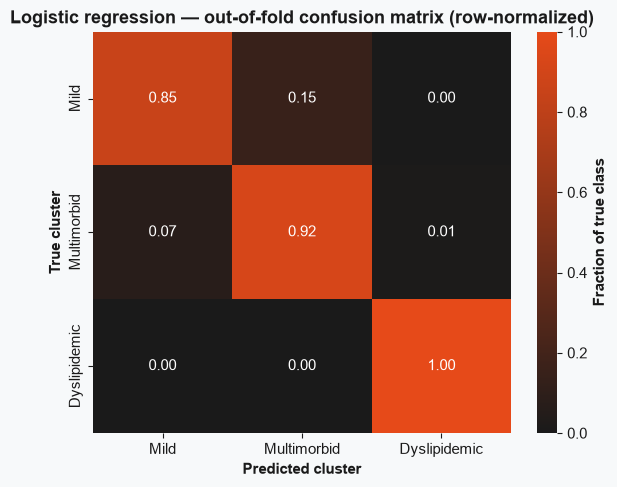

In [ ]:

# [Step 4 (continued)]: Confusion matrix, normalized by true class

from sklearn.metrics import confusion_matrix

set_project_style()

# Row-normalized: each row sums to 1, showing what fraction of each TRUE class
# was predicted into each class. This is the per-class recall, made visual.
labels_order = [
    "Mild, lower treatment intensity",
    "Multimorbid, high care complexity",
    "Dyslipidemic / metabolic"
]
labels_short = ["Mild", "Multimorbid", "Dyslipidemic"]  # display-only, shortened for axis readability

cm = confusion_matrix(y_train, y_train_pred_cv, labels=labels_order, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="project_mono",
    xticklabels=labels_short, yticklabels=labels_short,
    cbar_kws={"label": "Fraction of true class"}, ax=ax, vmin=0, vmax=1
)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
ax.set_title("Logistic regression — out-of-fold confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

**Confusion matrix interpretation**: confirms the precision/recall pattern above. The
confusion is concentrated almost entirely between Mild and Multimorbid, and it goes both
directions: 15% of true Mild patients are predicted as Multimorbid, and 7% of true
Multimorbid patients are predicted as Mild. Dyslipidemic is essentially perfectly separated
(100% correctly classified, no leakage into or out of it).

This is the expected signature of the treatment-naive feature design: CCI and
`encounters_per_year`, the features that most cleanly separate Mild from Multimorbid in
the original Fase 3 clustering, are deliberately excluded here. The baseline lipid panel
alone is enough to isolate Dyslipidemic almost perfectly, but the boundary between "mild"
and "high complexity" is genuinely harder to draw from baseline labs alone, a clinically
honest finding, not a modeling failure.

In [16]:
# [Step 5]: Random Forest via Stratified K-Fold CV

from sklearn.ensemble import RandomForestClassifier

# n_estimators=300 -> number of trees in the forest; more trees = more stable averaging,
#                      with diminishing returns past a few hundred (dataset is small, so fast anyway)
# class_weight="balanced" -> same rationale as logistic regression: rare-class errors count more
# random_state=42 -> reproducibility of the random sampling (bagging + feature subsets)
# n_jobs=-1 -> train trees in parallel using all available CPU cores
#
# Note: individual trees are NOT depth-limited here. Unlike a single decision tree (where you'd
# carefully restrict depth to avoid overfitting), a random forest lets each tree grow deep and
# relies on averaging across many such trees to control overfitting collectively.
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Raw, unscaled features -- no Pipeline/scaler needed for tree-based models (see explanation above)
cv_results_rf = cross_validate(
    rf, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=False
)

print("Macro-F1 per fold: ", cv_results_rf["test_f1_macro"].round(3))
print("Macro-F1 mean ± std:", cv_results_rf["test_f1_macro"].mean().round(3), "±", cv_results_rf["test_f1_macro"].std().round(3))

print("\nAccuracy per fold: ", cv_results_rf["test_accuracy"].round(3))
print("Accuracy mean ± std:", cv_results_rf["test_accuracy"].mean().round(3), "±", cv_results_rf["test_accuracy"].std().round(3))

Macro-F1 per fold:  [0.84  0.89  0.879 0.894 0.902]
Macro-F1 mean ± std: 0.881 ± 0.022

Accuracy per fold:  [0.858 0.89  0.901 0.911 0.908]
Accuracy mean ± std: 0.894 ± 0.019


**Step 5 — Random Forest vs logistic regression baseline**

**Setup**: `RandomForestClassifier(n_estimators=300, class_weight="balanced")`, raw
(unscaled) features, no `Pipeline` needed, since tree splits are scale-invariant and the
only imputed feature (`Creatinine`) uses a fixed clinical reference value rather than a
data-derived statistic. Same `StratifiedKFold(n_splits=5)` as the logistic regression run.

**Results**:
- Macro-F1: 0.881 ± 0.022 (vs. 0.877 ± 0.023 for logistic regression)
- Accuracy: 0.894 ± 0.019 (vs. 0.873 ± 0.020 for logistic regression)

**Initial read**: Random Forest's macro-F1 is only marginally higher than logistic
regression's, well within the fold-to-fold noise of both models (overlapping std ranges).
Accuracy, however, improved more noticeably (+2.1 points). The gap between accuracy and
macro-F1 has also widened slightly compared to logistic regression (accuracy now exceeds
macro-F1 by ~0.013, vs. macro-F1 slightly exceeding accuracy before), a possible early
signal that Random Forest's gain is concentrated more on the majority class than on the
minority ones. To be confirmed with a per-class breakdown before drawing conclusions.

In [17]:
# [Step 5 (continued)]: Per-class evaluation for Random Forest

y_train_pred_cv_rf = cross_val_predict(rf, X_train, y_train, cv=cv)

print(classification_report(y_train, y_train_pred_cv_rf))

                                   precision    recall  f1-score   support

         Dyslipidemic / metabolic       0.90      0.96      0.93        75
  Mild, lower treatment intensity       0.97      0.89      0.93      1042
Multimorbid, high care complexity       0.69      0.90      0.78       293

                         accuracy                           0.89      1410
                        macro avg       0.86      0.92      0.88      1410
                     weighted avg       0.91      0.89      0.90      1410



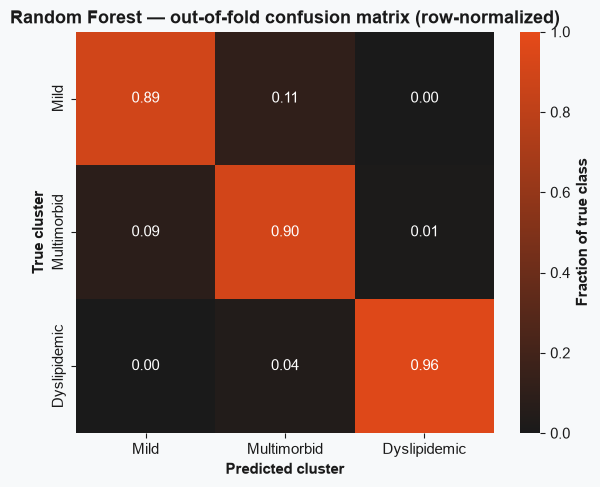

In [19]:
# 04_predictive_modeling.ipynb — Step 5 (continued): Confusion matrix for Random Forest

cm_rf = confusion_matrix(y_train, y_train_pred_cv_rf, labels=labels_order, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_rf, annot=True, fmt=".2f", cmap="project_mono",
    xticklabels=labels_short, yticklabels=labels_short,
    cbar_kws={"label": "Fraction of true class"}, ax=ax, vmin=0, vmax=1
)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
ax.set_title("Random Forest — out-of-fold confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

**Step 5 (continued) — Random Forest confusion matrix and trade-off vs logistic regression**

**Confusion matrix (Random Forest)**: Mild correctly classified 89% of the time (vs 85% for
logistic regression), Multimorbid 90% (vs 92%), Dyslipidemic 96% (vs a perfect 100%).

**Trade-off summary**:

| Confusion | Logistic regression | Random Forest |
|---|---|---|
| Mild → Multimorbid | 15% | 11% |
| Multimorbid → Mild | 7% | 9% |
| Dyslipidemic → Multimorbid | 0% | 4% |

The two models are not interchangeable despite the tied macro-F1 (0.877 vs 0.881), but the
nature of the trade-off needs to be stated precisely. Random Forest's higher Multimorbid F1
(0.78 vs 0.75) comes entirely from better **precision** (0.69 vs 0.64, fewer false
Multimorbid alarms), not from recall: logistic regression actually has the higher
Multimorbid **recall** (0.92 vs 0.90), meaning it misses fewer true Multimorbid patients.
Random Forest also gives up some of logistic regression's near-perfect Dyslipidemic
identification (96% vs 100%).

**Decision deferred at this point**: which error type matters more clinically, Mild/
Multimorbid precision vs. recall, or Dyslipidemic's small residual risk, was not yet
settled. Rather than picking a model on a narrow trade-off read from two models alone, the
next steps will be:<br>
**(1)** check feature importance for both models, partly to validate clinical
plausibility and rule out undue reliance on the known HbA1c/BMI synthetic-data artifact<br>
**(2)** test a third candidate, HistGradientBoosting, by building the trees sequentially, it is 
generally able to capture slightly more subtle non-linear patterns. It could positively shifts 
the trade-off, but this is a hypothesis that needs to be tested empirically.

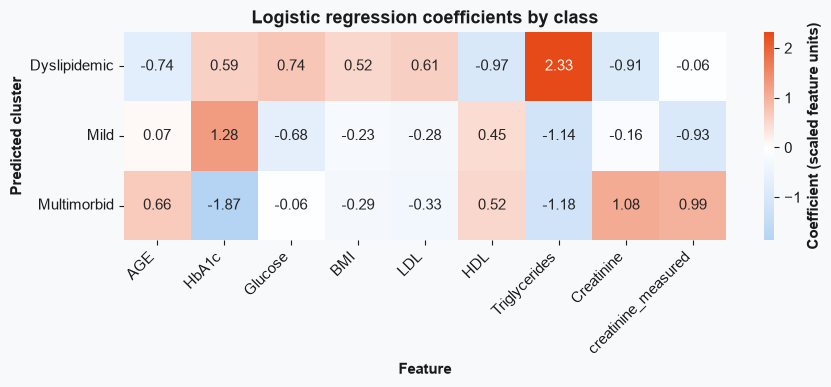

In [25]:
# [Step 7]: Feature importance (logistic regression coefficients)

# Fit on the full training set, this is for interpretation only, not for performance
# evaluation (that already happened via cross-validation in Step 4).
pipe.fit(X_train, y_train)

# Short label mapping
label_map = {
    "Mild, lower treatment intensity": "Mild",
    "Multimorbid, high care complexity": "Multimorbid",
    "Dyslipidemic / metabolic": "Dyslipidemic"
}


# Multinomial logistic regression learns one set of coefficients per class.
# Coefficients are directly comparable across features only because RobustScaler already
# put them on the same scale (median ~0, similar spread) -- on raw units they wouldn't be.
coefs = pd.DataFrame(
    pipe.named_steps["logreg"].coef_,
    columns=X_train.columns,
    index=pipe.named_steps["logreg"].classes_
)
coefs.index = coefs.index.map(label_map)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    coefs, annot=True, fmt=".2f", cmap="project_diverging", center=0, ax=ax,
    cbar_kws={"label": "Coefficient (scaled feature units)"}
)
ax.set_xlabel("Feature")
ax.set_ylabel("Predicted cluster")
ax.set_title("Logistic regression coefficients by class")
plt.setp(ax.get_yticklabels(), rotation=0, ha="right")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

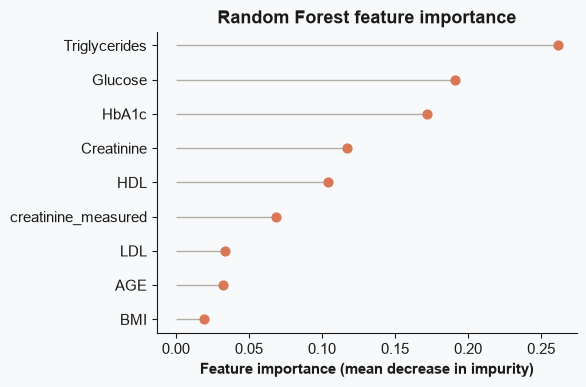

In [21]:
# 04_predictive_modeling.ipynb — Step 7 (continued): Feature importance (Random Forest)

rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hlines(importances.index, 0, importances.values, color="#b0aea5", linewidth=1, zorder=2)
ax.scatter(importances.values, importances.index, color="#d97757", zorder=3, s=40)
ax.set_xlabel("Feature importance (mean decrease in impurity)")
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.show()

**Step 7 — Feature importance: logistic regression vs Random Forest**

**Logistic regression coefficients** (scaled units, signed by effect direction):

- **Dyslipidemic**: dominated by `Triglycerides` (2.33, by far the largest coefficient in
  the table), with `HDL` (-0.97) and `Creatinine` (-0.91) reinforcing the metabolic profile, 
  consistent with the clinically expected lipid-driven phenotype.
- **Multimorbid**: driven by `HbA1c` (-1.87) together with `Creatinine` (+1.08) *and*
  `creatinine_measured` (+0.99). Notably, the model has independently recovered the
  Phase 2 missing-not-at-random signal, being tested for creatinine pushes toward
  Multimorbid almost as strongly as the value itself, confirming that engineering choice
  carries real signal.
- **Mild**: comparatively modest coefficients overall (mirror image of the other two
  classes), with `HbA1c` (+1.28) and `Triglycerides` (-1.14) the strongest.

**Random Forest feature importance** (unsigned, class-agnostic): top features are
`Triglycerides` > `Glucose` > `HbA1c` > `Creatinine` > `HDL`, converging well with the
logistic regression coefficients despite the two models being structurally very different
(linear vs. tree ensemble), a good sign that the pattern is genuine in the data, not an
artifact of one algorithm.

**Clinical hypothesis alignment**: Dyslipidemic's profile partially supports H1
(insulin-resistant phenotype); Multimorbid's reliance on creatinine/creatinine_measured
captures part of H3's renal-impairment component even without direct access to CCI.

**Caveat to document**: `HbA1c` ranks among the top 2-3 most influential features in both
models, despite being flagged in notebook 03 as showing Synthea-generated banding
(discrete synthetic states rather than natural clinical variation). `BMI`, the other
flagged variable, shows minimal importance in both models, so the exposure is limited to
one feature rather than both, but it remains an honest limitation to report: part of the
predictive signal rests on a variable with a known synthetic-data artifact.

**Model choice status**: still undecided. The Mild/Multimorbid vs. Dyslipidemic error
trade-off identified in Step 5-6 is unresolved by this analysis, feature importance adds
confidence that both models' signal is clinically coherent, but doesn't settle which
error pattern is preferable. **Decision deferred** until HistGradientBoosting (third
candidate) results are available.

In [26]:
# [Step 5c]: HistGradientBoosting via Stratified K-Fold CV

from sklearn.ensemble import HistGradientBoostingClassifier

# class_weight="balanced" -> same rationale as the other two models
# random_state=42 -> reproducibility
# (no n_estimators to set: HistGradientBoosting uses its own internal early-stopping
# logic by default, automatically deciding how many boosting rounds to run)
hgb = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=42
)

cv_results_hgb = cross_validate(
    hgb, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=False
)

print("Macro-F1 per fold: ", cv_results_hgb["test_f1_macro"].round(3))
print("Macro-F1 mean ± std:", cv_results_hgb["test_f1_macro"].mean().round(3), "±", cv_results_hgb["test_f1_macro"].std().round(3))

print("\nAccuracy per fold: ", cv_results_hgb["test_accuracy"].round(3))
print("Accuracy mean ± std:", cv_results_hgb["test_accuracy"].mean().round(3), "±", cv_results_hgb["test_accuracy"].std().round(3))

Macro-F1 per fold:  [0.872 0.912 0.918 0.915 0.875]
Macro-F1 mean ± std: 0.898 ± 0.02

Accuracy per fold:  [0.887 0.911 0.922 0.926 0.89 ]
Accuracy mean ± std: 0.907 ± 0.016


In [27]:
# [Step 5c (continued)]: Per-class evaluation for HistGradientBoosting

y_train_pred_cv_hgb = cross_val_predict(hgb, X_train, y_train, cv=cv)

print(classification_report(y_train, y_train_pred_cv_hgb))

                                   precision    recall  f1-score   support

         Dyslipidemic / metabolic       0.96      0.99      0.97        75
  Mild, lower treatment intensity       0.94      0.93      0.94      1042
Multimorbid, high care complexity       0.77      0.80      0.78       293

                         accuracy                           0.91      1410
                        macro avg       0.89      0.91      0.90      1410
                     weighted avg       0.91      0.91      0.91      1410



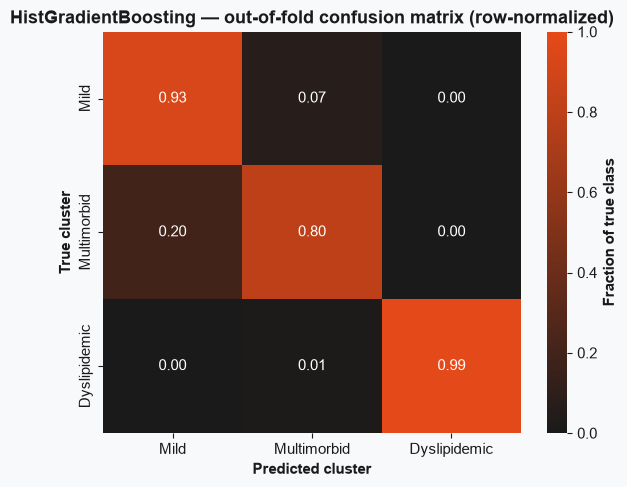

In [ ]:
# [Step 5c (continued)]: Confusion matrix for HistGradientBoosting

cm_hgb = confusion_matrix(y_train, y_train_pred_cv_hgb, labels=labels_order, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_hgb, annot=True, fmt=".2f", cmap="project_mono",
    xticklabels=labels_short, yticklabels=labels_short,
    cbar_kws={"label": "Fraction of true class"}, ax=ax, vmin=0, vmax=1
)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
ax.set_title("HistGradientBoosting — out-of-fold confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

**Model selection — final decision**

**Clinical priority established**: a Multimorbid patient (CCI 4.34, 6.35 encounters/year,
91% on insulin, Phase 3 profile) carries materially higher clinical risk than a
Dyslipidemic patient if missed at baseline. **Multimorbid recall is therefore the
deciding metric**.

**Recall on Multimorbid, all three models**: 
- logistic regression 0.92
- Random Forest 0.90
- HistGradientBoosting 0.80

HistGradientBoosting, despite the highest macro-F1 (0.898) and best Mild F1, achieves 
this partly by trading away Multimorbid recall (20% of true Multimorbid patients missed, 
vs 7-9% for the other two models), the opposite direction of what the clinical priority 
requires, so it is ruled out despite the stronger aggregate score.

**Final model: logistic regression.**<br> 
🗸 Best Multimorbid recall (0.92)<br>
🗸 Perfect Dyslipidemic recall (1.00)<br>
🗸 The most interpretable<br> 
The trade-off accepted: more Mild → Multimorbid confusion (15%, the highest of the three
models) than the alternatives, which is the lower-risk direction of error (over-triage of
a mild patient vs. under-triage of a complex one).

In [ ]:
# [Step 6]: Final evaluation on the untouched holdout test set

# Refit on the full training set (1410 patients), same fit as in Step 7, repeated here
# explicitly so this step is self-contained. The holdout test set has never been used
# for training or for any of the model-selection decisions made so far.
pipe.fit(X_train, y_train)

y_test_pred = pipe.predict(X_test)

print(classification_report(y_test, y_test_pred))

                                   precision    recall  f1-score   support

         Dyslipidemic / metabolic       0.90      1.00      0.95        19
  Mild, lower treatment intensity       0.98      0.84      0.90       261
Multimorbid, high care complexity       0.61      0.92      0.74        73

                         accuracy                           0.86       353
                        macro avg       0.83      0.92      0.86       353
                     weighted avg       0.90      0.86      0.87       353



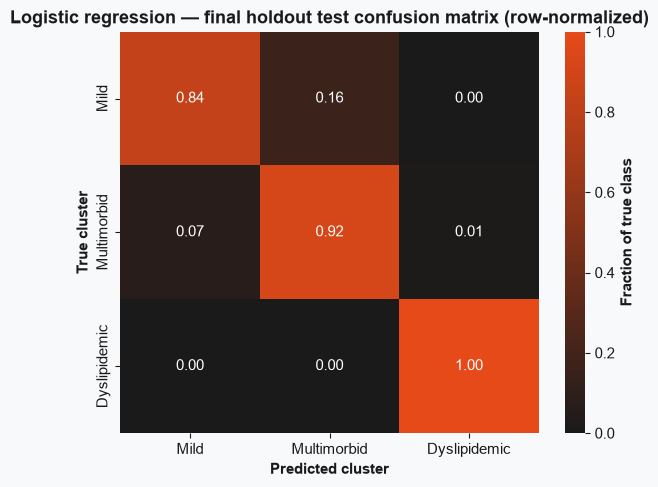

In [ ]:
# [Step 6 (continued)]: Confusion matrix on the holdout test set

cm_test = confusion_matrix(y_test, y_test_pred, labels=labels_order, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_test, annot=True, fmt=".2f", cmap="project_mono",
    xticklabels=labels_short, yticklabels=labels_short,
    cbar_kws={"label": "Fraction of true class"}, ax=ax, vmin=0, vmax=1
)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
ax.set_title("Logistic regression — final holdout test confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

**Step 8 — Final results and honest discussion**

**Final model**: logistic regression (`class_weight="balanced"`, `RobustScaler` fitted
within a `Pipeline`), selected over Random Forest and HistGradientBoosting based on an
explicit clinical priority, maximizing **Multimorbid recall**, rather than on aggregate
macro-F1 alone. HistGradientBoosting had the highest macro-F1 (0.898) but the worst
Multimorbid recall (0.80) of the three candidates, and was ruled out on that basis.

**Final holdout test performance** (n=353, untouched until this step):

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Dyslipidemic / metabolic | 0.90 | 1.00 | 0.95 | 19 |
| Mild, lower treatment intensity | 0.98 | 0.84 | 0.90 | 261 |
| Multimorbid, high care complexity | 0.61 | 0.92 | 0.74 | 73 |
| **Macro avg** | 0.83 | 0.92 | **0.86** | 353 |

**Holdout vs. cross-validation consistency**: macro-F1 (0.86 vs 0.877 ± 0.023) and
Multimorbid recall (0.92, identical to the CV estimate) both fall within the expected
range, confirming the model-selection decision generalizes to unseen patients rather than
reflecting an artifact of cross-validation or of the selection process itself.

**Answering the Phase 4 research question**: yes, baseline treatment-naive features can
meaningfully stratify patients into the three Phase 3 subtypes, even excluding the most
discriminative variables (CCI, `encounters_per_year`) by design. Performance is strongest
for Dyslipidemic (defined almost entirely by the baseline lipid panel) and good, though
imperfect, for the Mild/Multimorbid boundary, matching the moderate-performance
expectation flagged at the start of Phase 4 scoping rather than an engineered-away result.

**Limitations to carry into the final report**:
- Dyslipidemic test support is small (n=19); precision (0.90) has wider sampling
  uncertainty than the other two classes despite the strong point estimate.
- Multimorbid precision (0.61) remains the weakest spot: roughly 4 in 10 patients flagged
  as Multimorbid are false alarms (over-triage), an accepted trade-off given the explicit
  priority on not missing true Multimorbid patients.
- `HbA1c`, a top-3 feature by both coefficient magnitude and Random Forest importance, is
  known to carry a Synthea-generated banding artifact (notebook 03), part of the model's
  signal rests on a variable with this documented synthetic-data limitation.

**Future work**: a continuous treatment-adherence score (flagged in notebook 03) could be
explored as an additional baseline feature; a probability-threshold adjustment (rather than
the default 0.5 cutoff) could be tested as an alternative way to push Multimorbid recall
even higher, trading further into Mild/Multimorbid confusion if clinically justified.